In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
import os

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

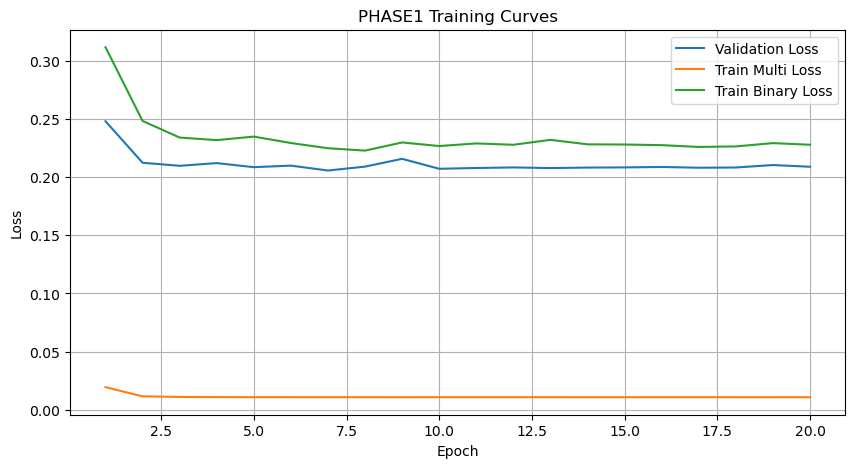

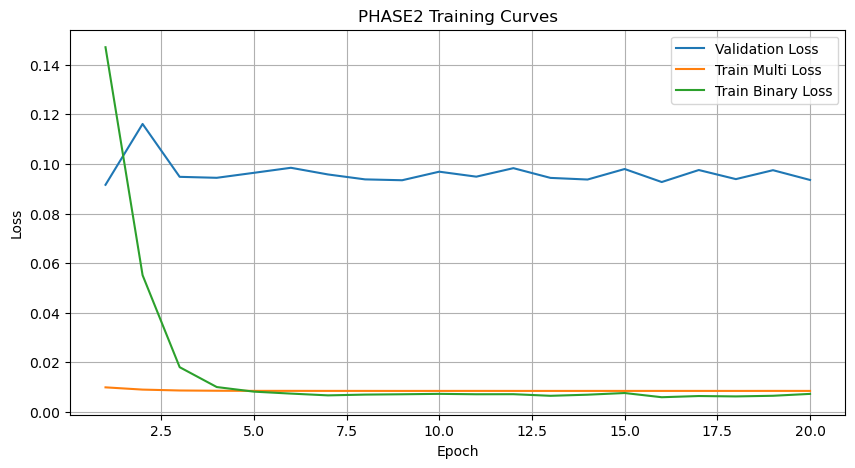

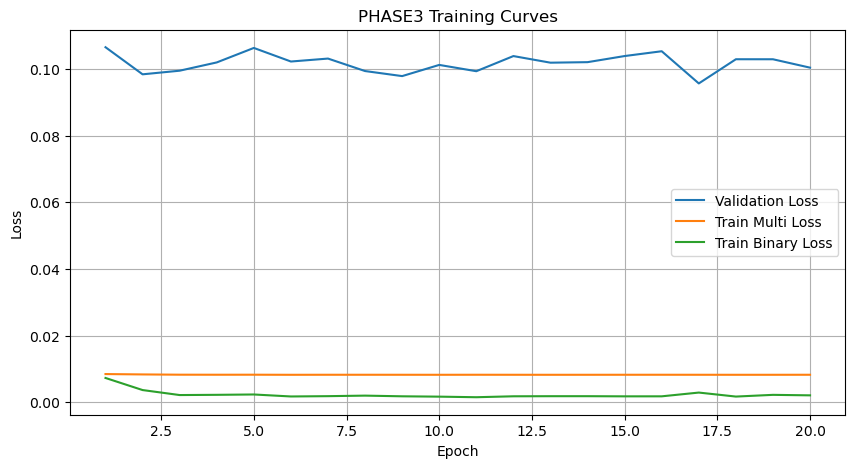

In [14]:
# Load metrics
with open("metrics.json", "r") as f:
    metrics = json.load(f)

def plot_phase(phase_name, data):
    epochs = range(1, len(data["val_loss"]) + 1)

    plt.figure(figsize=(10,5))
    
    plt.plot(epochs, data["val_loss"], label="Validation Loss")
    plt.plot(epochs, data["train_multi"], label="Train Multi Loss")
    plt.plot(epochs, data["train_binary"], label="Train Binary Loss")

    plt.title(f"{phase_name.upper()} Training Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()

    # Save for report
    #plt.savefig(f"{phase_name}_training_curve.png", dpi=300)
    plt.savefig(os.path.join(RESULTS_DIR, f"{phase_name}_training_curve.png"), dpi=300)
    plt.show()


# Plot all phases
for phase in ["phase1", "phase2", "phase3"]:
    plot_phase(phase, metrics[phase])

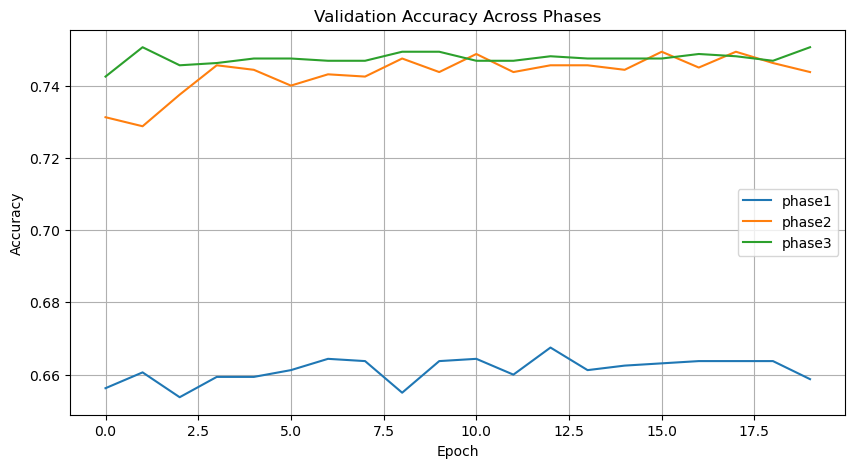

In [15]:
plt.figure(figsize=(10,5))

for phase in ["phase1", "phase2", "phase3"]:
    plt.plot(metrics[phase]["val_acc"], label=phase)

plt.title("Validation Accuracy Across Phases")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# plt.savefig("val_accuracy.png", dpi=300)
plt.savefig(os.path.join(RESULTS_DIR, "val_accuracy.png"), dpi=300)
plt.show()

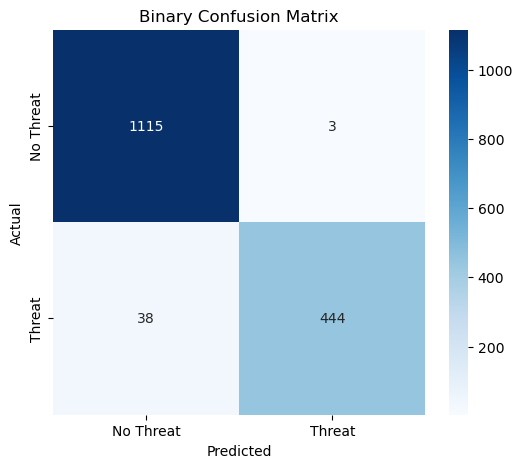

In [16]:
cm_binary = np.load("confusion_matrix_binary.npy")

plt.figure(figsize=(6,5))
sns.heatmap(cm_binary, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Threat", "Threat"],
            yticklabels=["No Threat", "Threat"])

plt.title("Binary Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# plt.savefig("binary_confusion_matrix.png", dpi=300)
plt.savefig(os.path.join(RESULTS_DIR, "binary_confusion_matrix.png"), dpi=300)
plt.show()

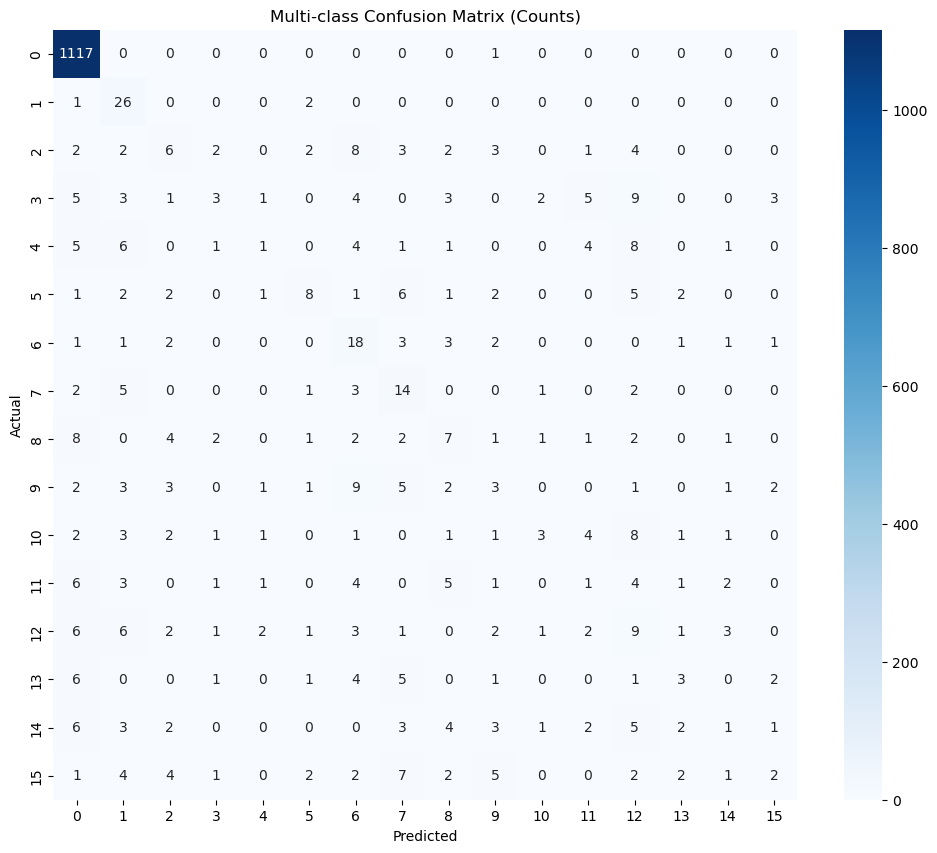

In [ ]:

cm_multi = np.load("confusion_matrix_multi.npy")

plt.figure(figsize=(12,10))
sns.heatmap(
    cm_multi,
    annot=True,      
    fmt="d", 
    cmap="Blues",        
)

plt.title("Multi-class Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(os.path.join(RESULTS_DIR, "multiclass_confusion_matrix_counts.png"), dpi=300)
plt.show()

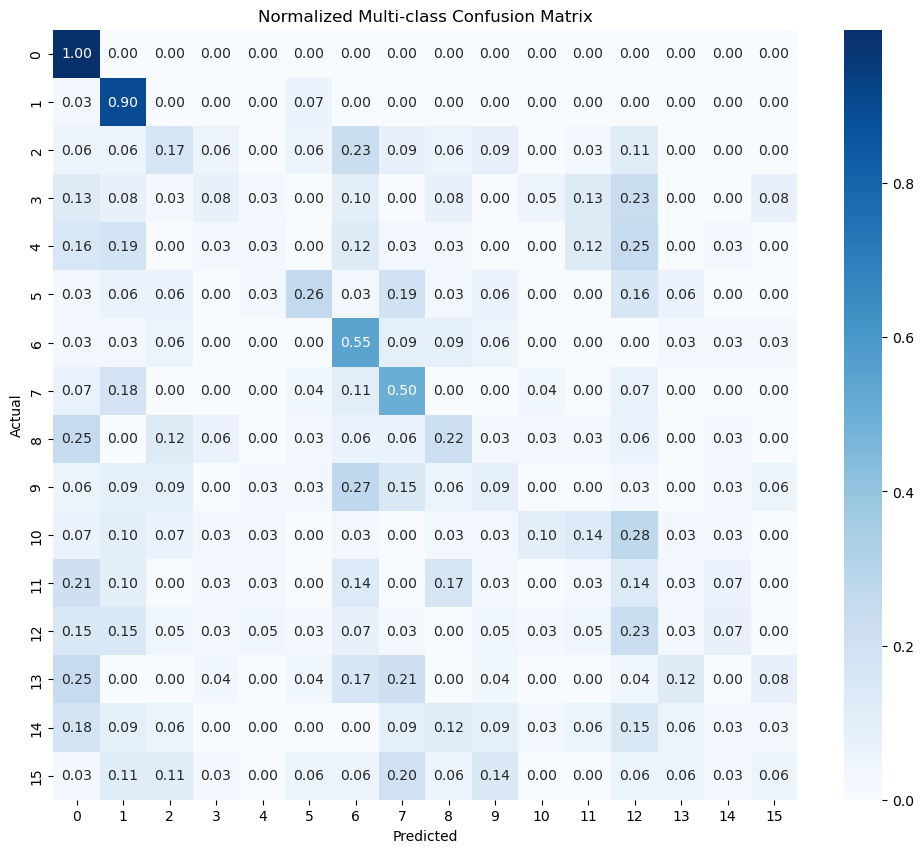

In [18]:
cm_multi = np.load("confusion_matrix_multi.npy")

# Normalize
cm_norm = cm_multi.astype('float') / cm_multi.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12,10))
sns.heatmap(
    cm_norm,
    annot=True,          
    fmt=".2f",          
    cmap="Blues",
    cbar=True
)

plt.title("Normalized Multi-class Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# plt.savefig("multiclass_confusion_matrix_numbers.png", dpi=300)
plt.savefig(os.path.join(RESULTS_DIR, "multiclass_confusion_matrix_percentage.png"), dpi=300)
plt.show()